# Pre-Canonical Inscriptions (NB 61)

Browser for the 6 inscriptions tagged `pre_canonical` in `data/quipu_data.csv`. After the May 2026 lenient title-region relaxation, only these structurally-divergent inscriptions remain pre-canonical — see `memory/pre_canonical_inscriptions.md` for the full record of what got reclassified as canonical.

Categories surfaced:
- **Non-structural image** (1) — Sparkle Magical Cat, no 12-byte structural header
- **Encrypted with non-canonical tone bytes** (4) — pre-tone-canonization test pairs
- **Pre-redesign celestial** (1) — old Sky of al-Jawza with kind=0x81 bit-packed flags

## Setup

In [15]:
import os, sys, json
REPO = os.path.abspath('..')
sys.path.insert(0, REPO)
sys.path.insert(0, os.path.join(REPO, 'canonical'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(os.path.join(REPO, 'data/quipu_data.csv'))
pre = df[df['canonical_status'] == 'pre_canonical'].copy()
print(f'{len(pre)} pre-canonical inscriptions:')
pre[['root_txid','type_name','label','title','total_bytes','blockheight']]

6 pre-canonical inscriptions:


,root_txid,type_name,label,title,total_bytes,blockheight
0,a2e9f2ebe1ceeae368b734fcd861549c813d5cfb009093...,image,apocrypha,NaN,2611,4221666
6,d68175766b70f7163aec93e5a4e81480a6c6dd51d05773...,encrypted,apocrypha,NaN,2800,4251800
7,d0209a0f85872d6826c58bc23fab37c8b21feb22c15a5a...,encrypted,apocrypha,NaN,15655,4252445
8,89b51b4852b0e80f49cdb229d85ef4757d943c9fe4ba62...,encrypted,apocrypha,NaN,112,4267974
9,f278e466012fb78422834742c6440c935f4cc2ef64e722...,encrypted,apocrypha,NaN,112,4270461
26,4e53bb26a432cc27996dda141b6fee5ac7a64d429394b3...,celestial,apocrypha,Sky of al-JawzaBʓ����SiriusB妨@�3 ProcyonB�...,1281,6210694


In [16]:
# Helper — load the body bytes for a row
def load_blob(row):
    return open(os.path.join(REPO, 'data', row['body_file']), 'rb').read()

# Helper — render a v1-shaped image quipu (with back-computed body offset)
def render_image_v1ish(row, ax=None):
    blob = load_blob(row)
    dims = json.loads(row['dimensions_json'])
    W, H, color, bd = dims['W'], dims['H'], dims['color'], dims['bit_depth']
    ch = 1 if color == 0 else 3
    expected_body = (W * H * ch * bd + 7) // 8
    body_offset = len(blob) - expected_body
    body = blob[body_offset:body_offset + expected_body]
    # Unpack MSB-first into a flat list of values
    bits = []
    for byte in body:
        for i in range(7, -1, -1):
            bits.append((byte >> i) & 1)
    total_vals = W * H * ch
    values = []
    for i in range(total_vals):
        v = 0
        for j in range(bd):
            v = (v << 1) | bits[i*bd + j]
        values.append(v)
    max_val = (1 << bd) - 1
    arr = np.array(values, dtype=np.float32) / max_val
    if ch == 1:
        arr = arr.reshape((H, W))
        cmap = 'gray'
    else:
        arr = arr.reshape((H, W, 3))
        cmap = None
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4*H/W if W else 4))
    ax.imshow(arr, cmap=cmap)
    ax.axis('off')
    return ax

## Category A — Non-structural image (1)

Magic + type byte ✓ but no 12-byte structural header — title text starts immediately after byte 5.

txid: a2e9f2ebe1ceeae368b734fcd861549c813d5cfb009093237f86b71f0048bda7
label: apocrypha  blockheight: 4221666
total bytes: 2611

bytes[0:6] (magic + type + tone): c1dd000103ff  — c1dd0001 03 ff
bytes[6:8] (where color/W_hi would be): 2020  — 0x20 0x20 (two spaces, not color)
byte 8: 0x05 = 5 — maybe bit depth?

Extracted text content (printable ASCII runs in cabeza region):
  title block: '\x05Sparkle\nMagical Cat'

Body region (everything after the title block):
  starts at offset 29, length 2582 bytes
  first 64 bytes: e29ca8f09f929c466f7665766572f09f929ce29ca80ae6f7bdef7bdef7adef5ad6b5ad6b5ad6b5ad6b5ad6b5ad6b5ad6b5ad6739d6739ce739ce318c6318def7

Attempt to render assuming various dimensions:


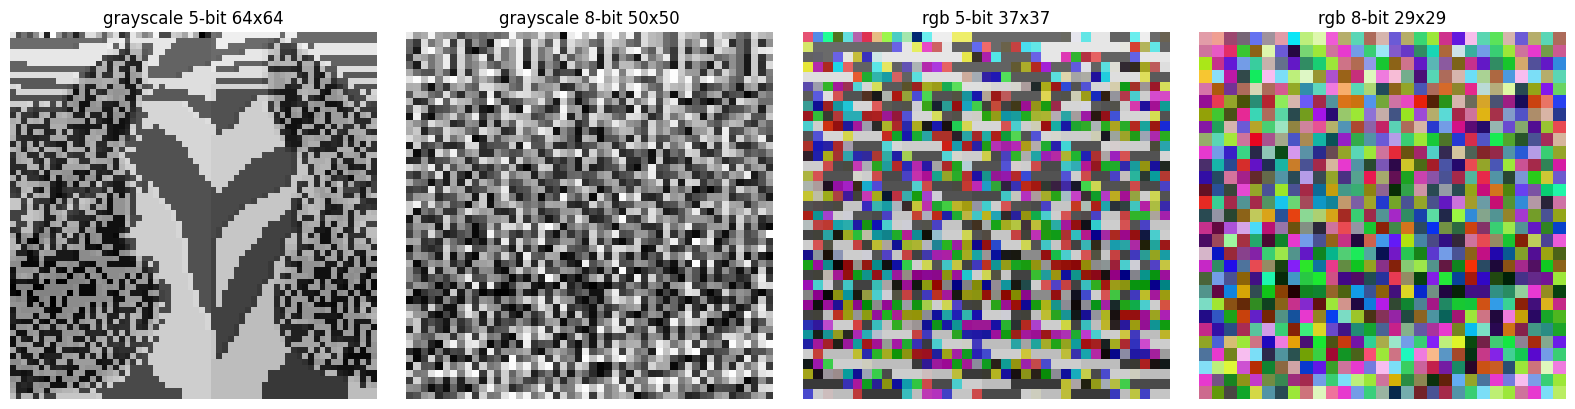

In [17]:
row = df[df['root_txid'].str.startswith('a2e9f2eb')].iloc[0]
blob = load_blob(row)
print(f'txid: {row["root_txid"]}')
print(f'label: {row["label"]}  blockheight: {row["blockheight"]}')
print(f'total bytes: {len(blob)}')
print()
print(f'bytes[0:6] (magic + type + tone): {blob[:6].hex()}  — c1dd0001 03 ff')
print(f'bytes[6:8] (where color/W_hi would be): {blob[6:8].hex()}  — 0x20 0x20 (two spaces, not color)')
print(f'byte 8: 0x{blob[8]:02x} = {blob[8]} — maybe bit depth?')
print()
print('Extracted text content (printable ASCII runs in cabeza region):')
import re
# Hunt for the title block in the first 100 bytes
cabeza_zone = blob[6:120]
title_match = re.match(rb'[\x20\x09\x0a-\x0d\x05\x20-\x7e]+', cabeza_zone)
if title_match:
    title_text = title_match.group(0).decode('utf-8', errors='replace').strip()
    print(f'  title block: {title_text!r}')

# Estimate where body might start
print()
print('Body region (everything after the title block):')
title_end = title_match.end() + 6 if title_match else 30
body = blob[title_end:]
print(f'  starts at offset {title_end}, length {len(body)} bytes')
print(f'  first 64 bytes: {body[:64].hex()}')
print()
print('Attempt to render assuming various dimensions:')
import numpy as np
import matplotlib.pyplot as plt
attempts = [
    ('grayscale 5-bit', 1, 5),
    ('grayscale 8-bit', 1, 8),
    ('rgb 5-bit', 3, 5),
    ('rgb 8-bit', 3, 8),
]
fig, axes = plt.subplots(1, len(attempts), figsize=(16, 4))
for ax, (label, ch, bd) in zip(axes, attempts):
    pixels = (len(body) * 8) // (ch * bd)
    side = int(pixels ** 0.5)
    if side < 8:
        ax.set_title(label + ' — only ' + str(pixels) + 'px (too small)')
        ax.axis('off')
        continue
    # Unpack bits
    bits = []
    for byte in body:
        for i in range(7, -1, -1):
            bits.append((byte >> i) & 1)
    n_pix = side * side
    values = []
    for i in range(n_pix * ch):
        v = 0
        for j in range(bd):
            idx = i*bd + j
            v = (v << 1) | (bits[idx] if idx < len(bits) else 0)
        values.append(v)
    max_val = (1 << bd) - 1
    arr = np.array(values, dtype=np.float32) / max_val
    if ch == 1:
        arr = arr.reshape((side, side))
        ax.imshow(arr, cmap='gray')
    else:
        arr = arr.reshape((side, side, 3))
        ax.imshow(arr)
    ax.set_title(label + ' ' + str(side) + 'x' + str(side))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Category D — Encrypted with non-canonical tone bytes (4)

Apocrypha encrypted-quipu test pairs from before tone was canonized to {0x00, 0x01, 0xff}. These used 0x03 and 0x0e as experimental tone values. The structural header is otherwise compatible with the 0x0e family. Encrypted bodies aren't decrypted here — keys are not in scope for this view.

In [18]:
# d68175↔89b51b and d0209a↔f278e4 are pre-canonical encrypted PAIRS:
# the d68175/d0209a inscriptions are sealed bodies; the 89b51b/f278e4 are
# the keydrop releases that pair with them. Both predate the 0xee family
# tone canonization — they use tones 0x03 (sealed) and 0x0e (drop).

print('=' * 70)
print('Pre-canonical encrypted PAIRS')
print('=' * 70)

PAIRS = [
    ('d6817576', '89b51b48', 'first pair'),
    ('d0209a0f', 'f278e466', 'second pair'),
]

for sealed_prefix, drop_prefix, label_pair in PAIRS:
    print('\n--- {label_pair} ---')
    for prefix, role in [(sealed_prefix, 'sealed'), (drop_prefix, 'drop')]:
        row = df[df['root_txid'].str.startswith(prefix)].iloc[0]
        blob = load_blob(row)
        print('\n  {role.upper()}: {row["root_txid"][:20]}…  ({row["label"]}, block {row["blockheight"]})')
        print(f'    total bytes: {len(blob)}')
        print(f'    bytes[0:8]:  {blob[:8].hex()}')
        # Try to extract title — many use |TITLE| or just plaintext
        rest = blob[8:200]
        # Find a pipe-bracketed string
        import re
        m = re.search(rb'\|([^\|]+)\|', rest)
        if m:
            print(f'    title:       {m.group(1).decode("utf-8", errors="replace")!r}')
        # If sub_family byte is 0x0d, this is a keydrop
        if blob[6] == 0x0d:
            print(f'    sub_family:  0x0d (DROP — releases keys)')
        # Show first body bytes after title
        if m:
            body_start = 8 + m.end()
            print(f'    body[0:32]:  {blob[body_start:body_start+32].hex()}')

Pre-canonical encrypted PAIRS

--- {label_pair} ---

  {role.upper()}: {row["root_txid"][:20]}…  ({row["label"]}, block {row["blockheight"]})
    total bytes: 2800
    bytes[0:8]:  c1dd00010e030000
    title:       'Here is an encrypted image going out to a very special lady...Wow'
    body[0:32]:  800aa57432997020913d7d8d881ccd149113b24722872755e260514661731397

  {role.upper()}: {row["root_txid"][:20]}…  ({row["label"]}, block {row["blockheight"]})
    total bytes: 112
    bytes[0:8]:  c1dd00010e0e0d7c
    sub_family:  0x0d (DROP — releases keys)

--- {label_pair} ---

  {role.upper()}: {row["root_txid"][:20]}…  ({row["label"]}, block {row["blockheight"]})
    total bytes: 15655
    bytes[0:8]:  c1dd00010e030100
    title:       'This is an encrypted image for two special ladies...Hola'
    body[0:32]:  c8554b3a976a42a354722c5500a04c7a97f966788acaf2f2e5a1932a4673b031

  {role.upper()}: {row["root_txid"][:20]}…  ({row["label"]}, block {row["blockheight"]})
    total bytes: 112
    byt

## Category E — Pre-redesign celestial (1)

The old Sky of al-Jawza inscription used the original bit-packed celestial format (kind byte with high-bit flags) before the May 2026 redesign that split kind/grouped/meta into separate bytes. Superseded by the canonical `2ae7fe90…` inscription.

In [19]:
# 4e53bb26 — old Sky of al-Jawza format. The body uses an undocumented
# pre-canonical convention: <title> 'B' <7 coord bytes> [<namelen><name> 'B' <coords>]+
# 'B' (0x42) appears to be a star-record marker, followed by 7 bytes of
# coordinate data, then length-prefixed star names that REPEAT this pattern.
row = df[df['root_txid'].str.startswith('4e53bb26')].iloc[0]
blob = load_blob(row)
print(f'txid: {row["root_txid"]}')
print(f'label: {row["label"]}  block: {row["blockheight"]}')
print(f'total bytes: {len(blob)}')
print(f'bytes[0:12]: {blob[:12].hex()}')
print(f'  c1dd0001 — magic  /  ce — type celestial  /  ff — tone reverence')
print(f'  byte 6 = 0x{blob[6]:02x} = bit-packed kind+flags (pre-redesign)')
print()

# Parse title (text until the first 'B' marker)
body = blob[7:]  # skip magic+type+tone+kind
b_pos = body.find(b'B')
if b_pos > 0:
    title_bytes = body[:b_pos].rstrip(b'\x00\x20')
    title = title_bytes.decode('utf-8', errors='replace').strip()
    print(f'Title: {title!r}')
    print()

# Walk through the body looking for the (B + 7 bytes + namelen + name) pattern
print('Star records (pattern: B<7-byte coords><namelen><name>):')
print(f'  {"#":3s}  {"name":15s}  coord bytes (hex)')
pos = b_pos + 1
star_records = []
while pos < len(body):
    if pos + 8 > len(body):
        break
    coord_bytes = body[pos:pos+7]
    namelen = body[pos+7]
    if namelen == 0 or namelen > 30:
        break
    if pos + 8 + namelen > len(body):
        break
    name_bytes = body[pos+8:pos+8+namelen]
    try:
        name = name_bytes.decode('utf-8')
        if not name.isprintable():
            break
    except UnicodeDecodeError:
        break
    star_records.append((name, coord_bytes))
    print(f'  {len(star_records):3d}  {name:15s}  {coord_bytes.hex()}')
    # Advance past the name to the next 'B'
    after_name = pos + 8 + namelen
    if after_name >= len(body) or body[after_name:after_name+1] != b'B':
        # Some records might not have trailing B
        pos = after_name
    else:
        pos = after_name + 1  # skip B

print('\nTotal stars recovered: {len(star_records)}')
print('\nFirst 3 coord-byte decodings (as 4-byte BE / LE / 2x int16):')
import struct
for name, cb in star_records[:3]:
    print(f'  {name:15s}  hex={cb.hex()}')
    print(f'    as 4-byte float BE (first 4):  {struct.unpack(">f", cb[:4])[0]:.4f}')
    print(f'    as 4-byte float LE (first 4):  {struct.unpack("<f", cb[:4])[0]:.4f}')
    print(f'    as int16 BE (bytes 1-2,3-4):   {struct.unpack(">hh", cb[1:5])}')
    print(f'    as int16 LE (bytes 1-2,3-4):   {struct.unpack("<hh", cb[1:5])}')

txid: 4e53bb26a432cc27996dda141b6fee5ac7a64d429394b307a08dd49cc7ec15cc
label: apocrypha  block: 6210694
total bytes: 1281
bytes[0:12]: c1dd0001ceff813e13546865
  c1dd0001 — magic  /  ce — type celestial  /  ff — tone reverence
  byte 6 = 0x81 = bit-packed kind+flags (pre-redesign)

Title: '>\x13The Sky of al-Jawza'

Star records (pattern: B<7-byte coords><namelen><name>):
  #    name             coord bytes (hex)
    1  Sirius           ca9307c185ba9d
    2  Procyon          e5a6a840a7331e
    3  Betelgeuse       b195fc40ed06a3
    4  Rigel            9d44d9c10339eb
    5  Bellatrix        a290c640cb30be
    6  Mintaka          a600dbbe992253
    7  Alnilam          a81b56bf99d884
    8  Alnitak          aa611fbff8a676
    9  Saiph            ade0d4c11ab6ae
   10  Meissa           a791b3411ef25c
   11  Naath            a7b76dc0bd1dd2
   12  Tabita           a7a318c0ac7842
   13  Arneb            a65d79c18e9408
   14  Nihal            a41f67c1a61355
   15  Gam Lep          ac3b5ac1b3957

## Estandarte v1 implications

Per `memory/pre_canonical_inscriptions.md`:

- 25 canonical_v1 inscriptions are available as canonical-example citations for Estandarte v1 (incl. the 8 reclassified by the lenient title-region rule).
- The 6 inscriptions shown above remain pre-canonical: 1 non-structural image, 4 encrypted with non-canonical tone bytes, 1 pre-redesign celestial. These are not cited as canonical examples.
- Estandarte v1 should register `0x0c` (the pre-canonical hash-cert that became 0xcc subtype 0x0001) with `status=3 deprecated`. That inscription (20db7d45) is in `data/quipu_data.csv` tagged `not_yet_canonicalized`.
- The non-structural 0x03 variant (a2e9f2eb) and the old celestial kind layout don't need their own Estandarte registrations — they're individual experiments, not separate types.